tensor([34.9596, 34.9260, 34.8253, 34.6580, 34.4250, 34.1276, 33.7673, 33.3460,
        32.8660, 32.3296, 31.7398, 31.0994, 30.4117, 29.6801, 28.9083, 28.0999,
        27.2589, 26.3892, 25.4947, 24.5796, 23.6478, 22.7034, 21.7503, 20.7925,
        19.8337, 18.8775, 17.9275, 16.9870, 16.0591, 15.1469, 14.2531, 13.3802,
        12.5305, 11.7061, 10.9088, 10.1403,  9.4017,  8.6944,  8.0190,  7.3763,
         6.7667,  6.1904,  5.6474,  5.1376,  4.6604,  4.2155,  3.8021,  3.4195,
         3.0667,  2.7426,  2.4462,  2.1762,  1.9313,  1.7102,  1.5116,  1.3341,
         1.1764,  1.0369,  0.9144,  0.8075,  0.7150,  0.6354,  0.5676,  0.5104,
         0.4627,  0.4234,  0.3915,  0.3660,  0.3462,  0.3312,  0.3202,  0.3126,
         0.3078,  0.3052,  0.3045,  0.3050,  0.3065,  0.3087,  0.3113,  0.3141,
         0.3169,  0.3195,  0.3219,  0.3239,  0.3256,  0.3268,  0.3276,  0.3280,
         0.3279,  0.3275,  0.3268,  0.3257,  0.3244,  0.3229,  0.3212,  0.3194,
         0.3176,  0.3157,  0.3138,  0.31

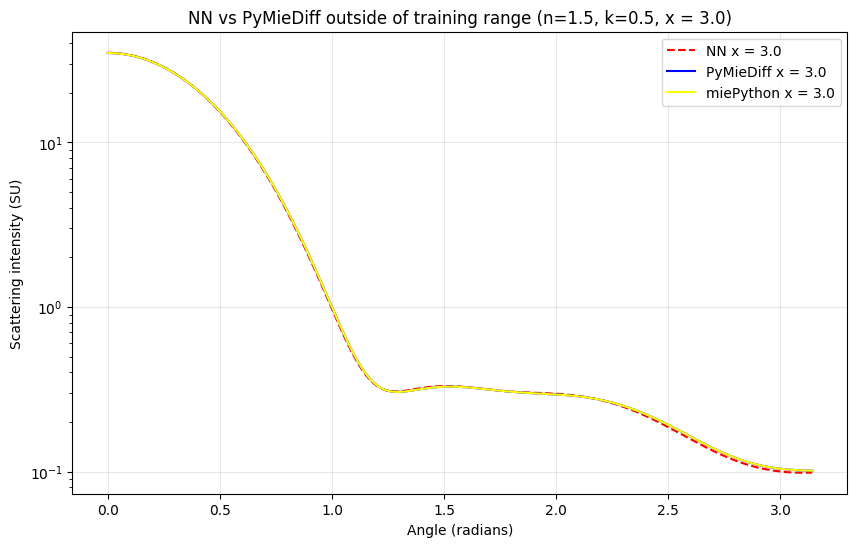

In [46]:
"""
mie_predictor.py — standalone Mie scattering inference using an ONNX model.
Dependencies: numpy, onnxruntime
"""

import numpy as np
import pymiediff as pmd
import onnxruntime
import matplotlib.pyplot as plt
import torch


class MiePredictor:

    # Normalization constants — set these to match how the model was trained
    N_MIN, N_MAX = 1.0, 1.9
    K_MIN, K_MAX = 0.5, 1.00
    X_MIN = np.pi * 100 / 650 
    X_MAX = np.pi * 1200 / 450 
    ASSUMED_WAVELENGTH = 500    # just for calculation purposes

    def __init__(self, onnx_path):
        # Load an ONNX model
        self.session = onnxruntime.InferenceSession(
            onnx_path, 
            providers=["CPUExecutionProvider"]
        )
        self.input_name = self.session.get_inputs()[0].name
    
    def predict(self, x, n, k, angle=None):
        """
        Function to predict Mie scattering intensity with onnx file
        
        Args:
            x: size parameter
            n: real part of refractive index
            k: imaginary part of refractive index
            angle: array of angles in radians. Defaults to 181 angles from 0 to π.
        
        Returns:
            numpy array of scattering intensities, one per angle.
        """
        if angle is None:
            angle = np.linspace(0, np.pi, 181)
        angle = np.asarray(angle)
        
        # Normalize inputs to [0, 1]
        n_norm = (n - self.N_MIN) / (self.N_MAX - self.N_MIN)
        k_norm = (k - self.K_MIN) / (self.K_MAX - self.K_MIN)
        x_norm = (x - self.X_MIN) / (self.X_MAX - self.X_MIN)
        theta_norm = angle / np.pi
        
        # Build (n_angles, 4) batch — one row per angle, n/k/x repeated
        batch = np.stack([
            np.full_like(theta_norm, n_norm),
            np.full_like(theta_norm, k_norm),
            np.full_like(theta_norm, x_norm),
            theta_norm
        ], axis=1).astype(np.float32)
        
        # Run inference
        log_pred = self.session.run(None, {self.input_name: batch})[0]
        
        # Un-log to get physical intensity
        # 181 intensity values for each angle in radians
        return 10 ** log_pred.flatten()

# wrapper function for generating pyMieDiff phase functions
def py_Mie_Diff_Scattering(wavelength, diameter, n, k, environment_value = 1.00):
    # - setup the particle
    wl0 = torch.tensor([wavelength]) # converting into what pyMieDiff requires as input
    k0 = 2 * torch.pi / wl0

    p = pmd.Particle(
        r_layers=[diameter/2],
        mat_layers=[n + k*1j],
        mat_env = 1.00
    )

    theta = torch.arange(0, 181) * torch.pi/181
    
    angle_scattering = p.get_angular_scattering(k0= k0, theta = theta)
    # returns 181 intensity values
    return angle_scattering['i_unpol']
def mie_python_Scattering(x, n, k):
    m = n - k*1j          # refractive index, n=1.5, k=0.01
    x = 3.0                  # size parameter
    theta = np.linspace(0, 180, 181)   # degrees, 0 = forward, 180 = backward
    mu = np.cos(np.radians(theta))     # just cos(theta), same info, different variable
    scat = mie.i_unpolarized(m, x, mu)    # scattering intensity at each theta
    return scat

# example of running the code
x = 3.0
n = 1.5
k = 0.5

# change to the name of the onnx file
predictor = MiePredictor("mie_scattering_NN_D(100-1200)_W(450-650)_N(1.0-1.9)_k(0.5-1.0).onnx")
curve_truth = predictor.predict(x, n, k)

# have to convert x to diameter and wavelength when running pyMieDiff
# assumed wavelength is 500
curve_NN = py_Mie_Diff_Scattering(500, (500 * x)/(np.pi), n, k)
print(curve_NN)

import miepython as mie

m = 1.5 - 0.5j          # refractive index, n=1.5, k=0.01
x = 3.0                  # size parameter
theta = np.linspace(0, 180, 181)   # degrees, 0 = forward, 180 = backward
mu = np.cos(np.radians(theta))     # just cos(theta), same info, different variable

scat = mie.i_unpolarized(m, x, mu)    # scattering intensity at each theta

ratio = curve_NN.numpy() / scat   # or curve_truth / scat
print("debuggin")
print(curve_truth / scat)
print(ratio.min(), ratio.max(), ratio.mean(), ratio.std())

# plotting example
angles = np.linspace(0, 180, 181) * np.pi / 180
plt.figure(figsize=(10, 6))
plt.plot(angles, curve_truth, label= f"NN x = {x}", color='red', linestyle='--')
plt.plot(angles, curve_NN, label = f"PyMieDiff x = {x}", color= 'blue', linestyle = '-')
plt.plot(angles, scat*ratio, label = f"miePython x = {x}", color='yellow', linestyle='-')
plt.xlabel("Angle (radians)")
plt.ylabel("Scattering intensity (SU)")
plt.title(f"NN vs PyMieDiff outside of training range (n=1.5, k=0.5, x = 3.0)")
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


Computing Brightness for Each Diameter with PyMieDiff
  x = 31.8 (0/1200)
  x = 45.1 (100/1200)
  x = 63.9 (200/1200)
  x = 90.5 (300/1200)
  x = 128.1 (400/1200)
  x = 181.5 (500/1200)
  x = 257.1 (600/1200)
  x = 364.1 (700/1200)
  x = 515.8 (800/1200)
  x = 730.6 (900/1200)
  x = 1034.8 (1000/1200)
  x = 1465.8 (1100/1200)
Computing Brightness for Each Diameter with NN
  x = 2069.0 (0/1200)
  x = 2069.0 (100/1200)
  x = 2069.0 (200/1200)
  x = 2069.0 (300/1200)
  x = 2069.0 (400/1200)
  x = 2069.0 (500/1200)
  x = 2069.0 (600/1200)
  x = 2069.0 (700/1200)
  x = 2069.0 (800/1200)
  x = 2069.0 (900/1200)
  x = 2069.0 (1000/1200)
  x = 2069.0 (1100/1200)
x range: 0 to 13
Training was: () to 1200 nm


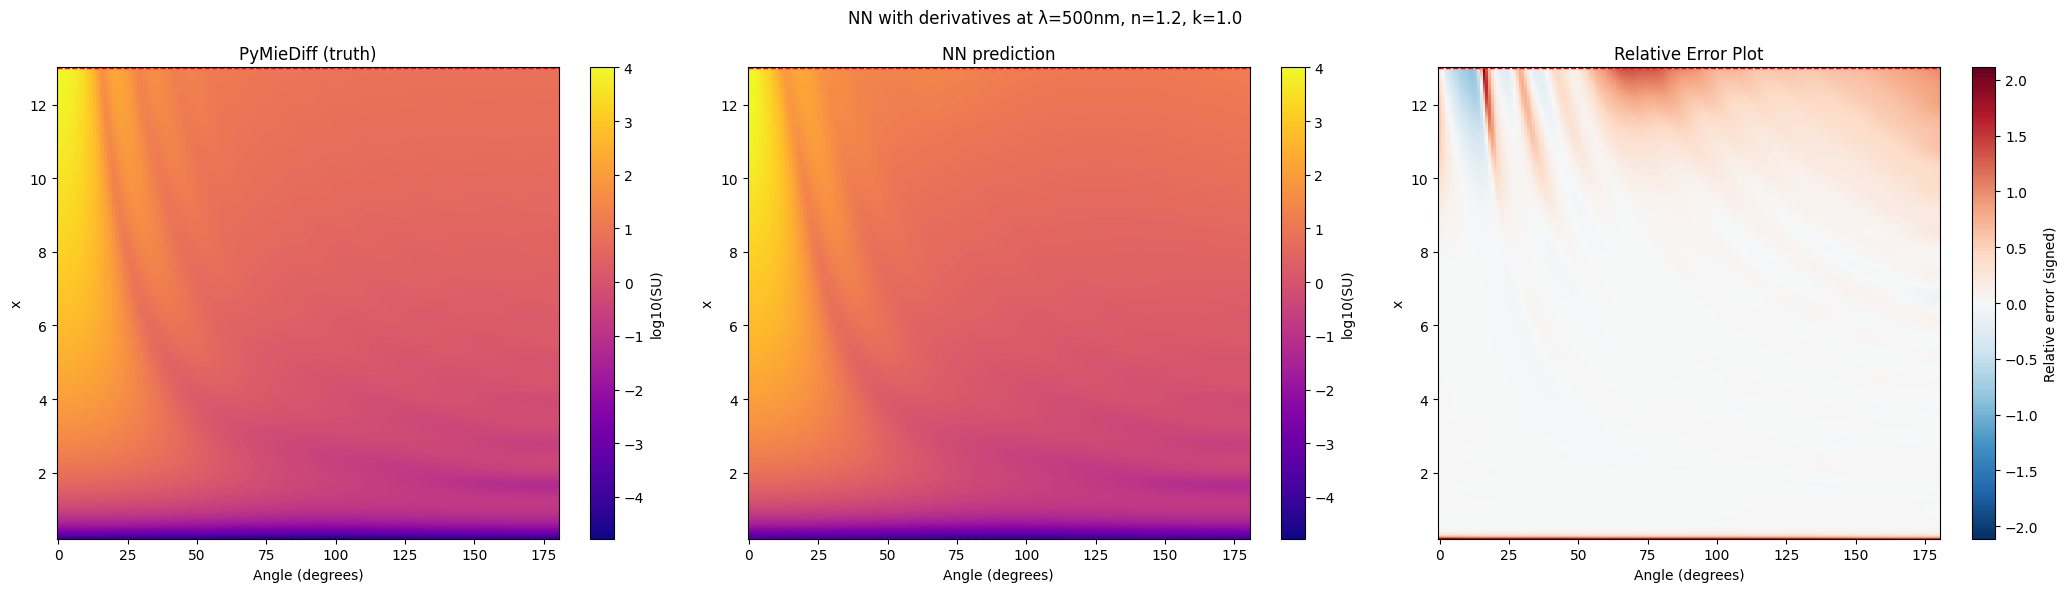

In [3]:
# creating 2D plot

N_D_SPANNING_DATA = 1200
n = 1.2
k = 1.0
fixed_lambda = 500
x_minimum = 0.2
x_maximum = 13
x_span = np.logspace(np.log10(x_minimum), np.log10(x_maximum), N_D_SPANNING_DATA)
print("Computing Brightness for Each Diameter with PyMieDiff")
truth = np.zeros((N_D_SPANNING_DATA, 181)) # create array of 181 arrays which have values of 0

# generate the pyMieDiff curves for each diameter
for i, x in enumerate(x_span):
    d = x * fixed_lambda / np.pi
    curve = py_Mie_Diff_Scattering(fixed_lambda, d, n, k).numpy()
    truth[i, :] = curve

    if i % 100 == 0:
        print(f"  x = {d:.1f} ({i}/{N_D_SPANNING_DATA})")


# generate the NN predictions for each diameter
print("Computing Brightness for Each Diameter with NN")

nn_pred = np.zeros((N_D_SPANNING_DATA, 181))

for id, x in enumerate(x_span):
    curve = predictor.predict(x, n, k)
    nn_pred[id, :] = curve

    if id % 100 == 0:
        print(f"  x = {d:.1f} ({id}/{N_D_SPANNING_DATA})")

relative_error = (nn_pred - truth)/truth

print(f"x range: {x_span[0]:.0f} to {x_span[-1]:.0f}")
print(f"Training was: () to 1200 nm")

log_truth = np.log10(truth)
log_nn = np.log10(nn_pred)

vmin = log_truth.min()
vmax = log_truth.max()

import numpy as np
import matplotlib.colors as mcolors

angles = np.linspace(0, 180, 181)   # the 181 angle columns

fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# --- truth ---
m1 = axes[0].pcolormesh(angles, x_span, log_truth,
                        cmap='plasma', vmin=vmin, vmax=vmax, shading='auto')
# axes[0].set_yscale('log')
axes[0].set_title("PyMieDiff (truth)")
axes[0].set_xlabel("Angle (degrees)"); axes[0].set_ylabel("x")
plt.colorbar(m1, ax=axes[0], label='log10(SU)')

# --- NN ---
m2 = axes[1].pcolormesh(angles, x_span, log_nn,
                        cmap='plasma', vmin=vmin, vmax=vmax, shading='auto')
# axes[1].set_yscale('log')
axes[1].set_title("NN prediction")
axes[1].set_xlabel("Angle (degrees)"); axes[1].set_ylabel("x")
plt.colorbar(m2, ax=axes[1], label='log10(SU)')

# --- signed relative error, diverging, white at 0 ---
vlim = np.abs(relative_error).max()
m3 = axes[2].pcolormesh(angles, x_span, relative_error, cmap='RdBu_r',
                        norm=mcolors.TwoSlopeNorm(vmin=-vlim, vcenter=0.0, vmax=vlim),
                        shading='auto')
# axes[2].set_yscale('log')
axes[2].set_title("Relative Error Plot")
axes[2].set_xlabel("Angle (degrees)"); axes[2].set_ylabel("x")
plt.colorbar(m3, ax=axes[2], label='Relative error (signed)')

# Mark training range boundaries
x_train_min = x_minimum   # ≈ 546
x_train_max = x_maximum   # ≈ 1000

for ax in axes:
    ax.axhline(y=x_train_min, color='red', linestyle='--', linewidth=1)
    ax.axhline(y=x_train_max, color='red', linestyle='--', linewidth=1)

plt.suptitle(f"NN with derivatives at λ={fixed_lambda}nm, n={n}, k={k}")
plt.tight_layout()
plt.show()

In [7]:
"""pyMieDiff wrappers: forward scattering computation, used both for training-data
generation (with autograd derivatives) and as ground truth for benchmarking/plots."""
 
import torch
import pymiediff as pmd

def normalize(value, value_min, value_range):
    return (value - value_min) / value_range


def denormalize(normalized_value, value_min, value_range):
    return normalized_value * value_range + value_min
 
def py_Mie_Diff_Scattering(wavelength, diameter, n, k, environment_value=1.00):
    """Direct pyMieDiff call for a single (wavelength, diameter, n, k) particle.
    Returns unpolarized scattering intensity across all 181 angles (0 to 180 deg).
    Used for ground-truth curves and benchmarking, not for training (no autograd)."""
    wl0 = torch.tensor([wavelength])
    k0 = 2 * torch.pi / wl0
 
    p = pmd.Particle(
        r_layers=[diameter / 2],
        mat_layers=[n + k * 1j],
        mat_env=environment_value,
    )
 
    theta = torch.arange(0, 181) * torch.pi / 181
    angle_scattering = p.get_angular_scattering(k0=k0, theta=theta)
    return angle_scattering["i_unpol"]
 
 
def compute_log_scattering(n_norm, k_norm, x_norm, theta_norm):
    """Differentiable forward pass: normalized (n, k, x, theta) -> log10 scattering.
    Used inside torch.autograd.functional.jacobian during data generation to get
    ground-truth derivatives w.r.t. each normalized input.
    Pulls ranges/constants from data.py (deferred import — data.py imports this
    module at load time, so this avoids a circular import)."""
 
    x = denormalize(x_norm, X_MIN, X_RANGE)
 
    wavelength = ASSUMED_WAVELENGTH
    diameter = x * ASSUMED_WAVELENGTH / torch.pi
    n = denormalize(n_norm, N_MIN, N_RANGE)
    k = denormalize(k_norm, K_MIN, K_RANGE)
    theta_rad = denormalize(theta_norm, 0, torch.pi)
 
    particle = pmd.Particle(
        r_layers=torch.stack([diameter / 2]),
        mat_layers=[n + 1j * k],   # tensor-based complex preserves gradients
        mat_env=1.00,
    )
 
    k0 = 2 * torch.pi / wavelength
    scattering = particle.get_angular_scattering(k0=k0, theta=theta_rad)
    return torch.log10(scattering["i_unpol"])

In [16]:
import time

# --- data generation ---
N_PARTICLES = 500
N_ANGLES = 181
ASSUMED_WAVELENGTH = 500.0   # nm, used to convert x <-> diameter

# --- physical parameter ranges (uniform log-sampling for wavelength/diameter) ---
W_MAX = 650.0
W_MIN = 450.0
W_RANGE = W_MAX - W_MIN

D_MAX = 1200.0
D_MIN = 100.0
D_RANGE = D_MAX - D_MIN

X_MAX = (np.pi * D_MAX) / W_MIN
X_MIN = (np.pi * D_MIN) / W_MAX
X_RANGE = X_MAX - X_MIN

N_MAX = 1.9
N_MIN = 1.0
N_RANGE = N_MAX - N_MIN

K_MAX = 1.00
K_MIN = 0.5
K_RANGE = K_MAX - K_MIN

# --- train/test split ---
TRAIN_FRACTION = 0.8

def generate_dataset(plot_first_n: int = 10, show_plot: bool = True):
    """Generate N_PARTICLES particles x N_ANGLES angles, computing scattering and
    its Jacobian (d scattering / d[n, k, x, theta]) via torch.autograd.functional.jacobian.
    Saves to cache/data/*.npy and returns (inputs, outputs, derivatives), each
    flattened to (N_PARTICLES * N_ANGLES, 4) / (..., 1) / (..., 4).
    """

    particle_inputs = np.zeros((N_PARTICLES, N_ANGLES, 4))
    particle_outputs = np.zeros((N_PARTICLES, N_ANGLES))
    particle_derivatives = np.zeros((N_PARTICLES, N_ANGLES, 4))

    if show_plot:
        import matplotlib.pyplot as plt
        fig, axes = plt.subplots(5, 1, figsize=(10, 16), sharex=True)

    print(f"Generating {N_PARTICLES} particles with jacobians...")
    start_time = time.time()

    for p in range(N_PARTICLES):
        wavelength = 10 ** torch.tensor(np.random.uniform(np.log10(W_MAX), np.log10(W_MIN)))
        diameter = 10 ** torch.tensor(np.random.uniform(np.log10(D_MAX), np.log10(D_MIN)))
        n = torch.tensor(np.random.uniform(N_MIN, N_MAX))
        k = torch.tensor(np.random.uniform(K_MIN, K_MAX))
        x = diameter * np.pi / wavelength
        theta = torch.tensor(np.linspace(0, np.pi, N_ANGLES))

        n_norm = normalize(n, N_MIN, N_RANGE)
        k_norm = normalize(k, K_MIN, K_RANGE)
        x_norm = normalize(x, X_MIN, X_RANGE)
        theta_norm = normalize(theta, 0, np.pi)

        jacobian_derivative = torch.autograd.functional.jacobian(
            compute_log_scattering,
            (n_norm, k_norm, x_norm, theta_norm),
            vectorize=True,
        )

        with torch.no_grad():
            log_scattering = compute_log_scattering(n_norm, k_norm, x_norm, theta_norm)
            scattering = 10 ** log_scattering

        particle_inputs[p, :, 0] = n
        particle_inputs[p, :, 1] = k
        particle_inputs[p, :, 2] = x
        particle_inputs[p, :, 3] = theta

        particle_outputs[p, :] = scattering.numpy()

        particle_derivatives[p, :, 0] = jacobian_derivative[0].numpy()
        particle_derivatives[p, :, 1] = jacobian_derivative[1].numpy()
        particle_derivatives[p, :, 2] = jacobian_derivative[2].numpy()
        particle_derivatives[p, :, 3] = jacobian_derivative[3].diag().numpy()

        if show_plot and p < plot_first_n:
            print(f"Particle {p} — n={n:.2f}, k={k:.2f}, λ={wavelength:.1f}nm, d={diameter:.1f}nm")
            angles = theta_norm.numpy() * np.pi
            axes[0].plot(angles, scattering.numpy(), alpha=0.5)
            axes[1].plot(angles, jacobian_derivative[0].detach().numpy(), alpha=0.5)
            axes[2].plot(angles, jacobian_derivative[1].detach().numpy(), alpha=0.5)
            axes[3].plot(angles, jacobian_derivative[2].detach().numpy(), alpha=0.5)
            axes[4].plot(angles, jacobian_derivative[3].diag().detach().numpy(), alpha=0.5)

        if p % 25 == 0:
            elapsed = time.time() - start_time
            print(f"  particle {p}/{N_PARTICLES}  ({elapsed:.1f}s elapsed)")

    total_time = time.time() - start_time
    print(f"\nDone! Total time: {total_time:.1f}s ({total_time / N_PARTICLES:.2f}s per particle)")

    if show_plot:
        axes[0].set_ylabel("Brightness")
        axes[0].set_title("First 10 particles — Mie scattering and all derivatives")
        axes[0].set_yscale("log")
        axes[1].set_ylabel("∂/∂n")
        axes[2].set_ylabel("∂/∂k")
        axes[3].set_ylabel("∂/∂x")
        axes[4].set_ylabel("∂/∂θ")   # diameter derivative is broken in pyMieDiff autograd; not stored
        axes[4].set_xlabel("Angle (radians)")
        for ax in axes:
            ax.grid(True, alpha=0.3)
            ax.axhline(y=0, color="black", linewidth=0.5)
        plt.tight_layout()
        plt.show()

    inputs = particle_inputs.reshape(-1, 4)
    outputs = particle_outputs.reshape(-1, 1)
    derivatives = particle_derivatives.reshape(-1, 4)

    return inputs, outputs, derivatives

Generating 500 particles with jacobians...
Particle 0 — n=1.82, k=0.83, λ=548.8nm, d=946.8nm
  particle 0/500  (0.6s elapsed)
Particle 1 — n=1.05, k=0.61, λ=538.9nm, d=410.9nm
Particle 2 — n=1.17, k=0.59, λ=474.5nm, d=255.7nm
Particle 3 — n=1.49, k=0.76, λ=571.5nm, d=260.1nm
Particle 4 — n=1.76, k=0.85, λ=472.2nm, d=141.2nm
Particle 5 — n=1.86, k=0.52, λ=562.7nm, d=614.5nm
Particle 6 — n=1.24, k=0.99, λ=517.8nm, d=146.6nm
Particle 7 — n=1.24, k=0.95, λ=469.3nm, d=731.3nm
Particle 8 — n=1.55, k=0.57, λ=624.4nm, d=751.2nm
Particle 9 — n=1.54, k=0.63, λ=526.6nm, d=287.1nm
  particle 25/500  (9.8s elapsed)
  particle 50/500  (19.4s elapsed)
  particle 75/500  (29.3s elapsed)
  particle 100/500  (39.9s elapsed)
  particle 125/500  (50.9s elapsed)
  particle 150/500  (63.6s elapsed)
  particle 175/500  (74.0s elapsed)
  particle 200/500  (86.9s elapsed)
  particle 225/500  (97.6s elapsed)
  particle 250/500  (108.3s elapsed)
  particle 275/500  (120.1s elapsed)
  particle 300/500  (131.2s el

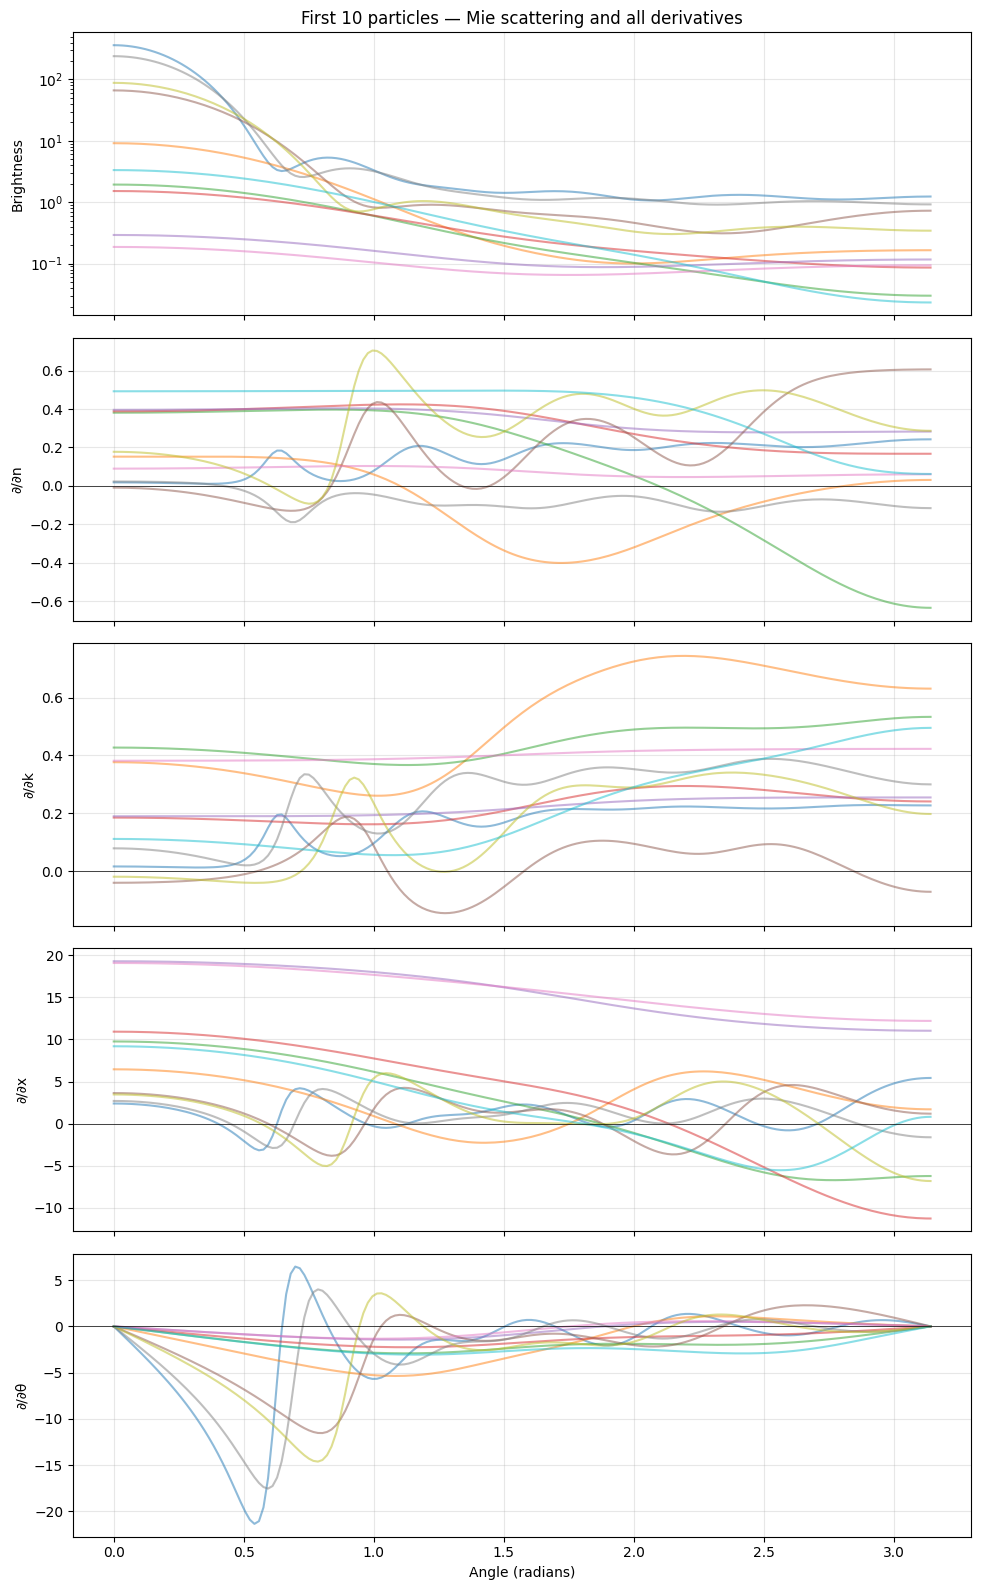

In [17]:
inputs, outputs, derivatives = generate_dataset()

Generating 500 random test particles...
  particle 0/500  (n=1.63, k=0.61, x=0.61)
  particle 50/500  (n=1.11, k=0.78, x=3.54)
  particle 100/500  (n=1.46, k=0.85, x=0.83)
  particle 150/500  (n=1.15, k=0.64, x=2.77)
  particle 200/500  (n=1.49, k=0.97, x=5.01)
  particle 250/500  (n=1.19, k=0.62, x=1.61)
  particle 300/500  (n=1.01, k=0.69, x=0.81)
  particle 350/500  (n=1.64, k=0.70, x=7.75)
  particle 400/500  (n=1.41, k=0.95, x=6.59)
  particle 450/500  (n=1.08, k=0.54, x=0.56)

Done. Mean relative error: 0.0096, 90th percentile: 0.0203


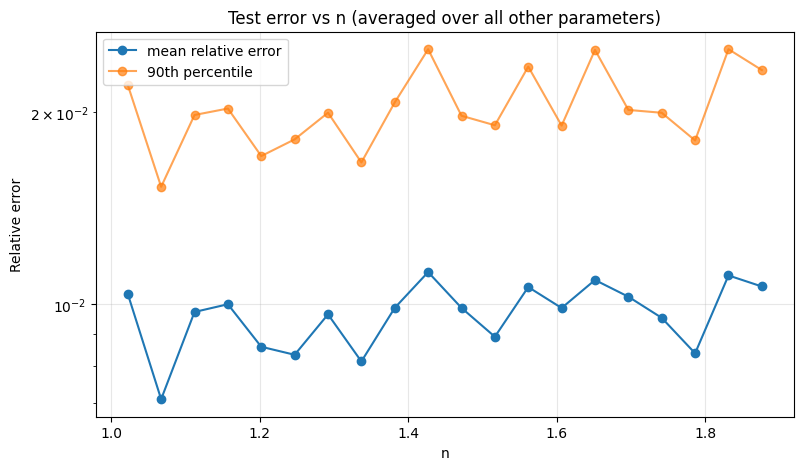

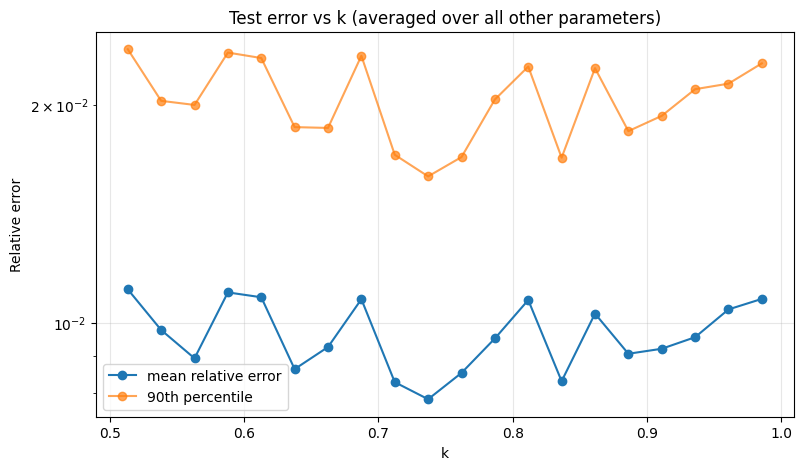

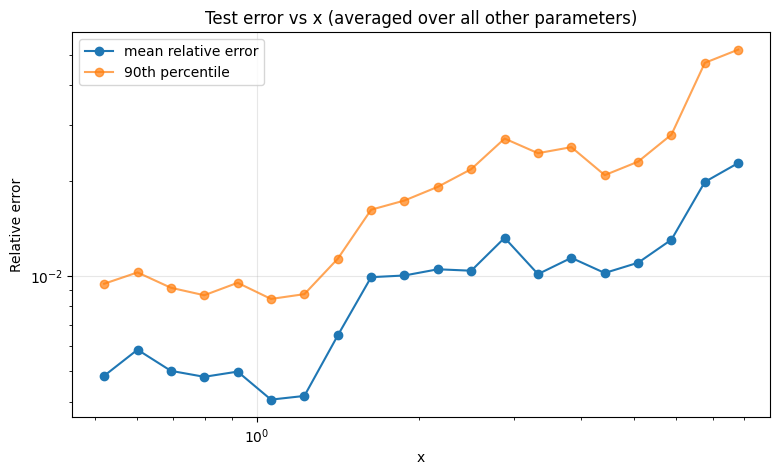

(array([0.52052913, 0.600288  , 0.69226806, 0.7983419 , 0.92066906,
        1.06174   , 1.22442674, 1.41204141, 1.62840363, 1.87791829,
        2.16566521, 2.49750259, 2.88018627, 3.32150724, 3.8304503 ,
        4.41737695, 5.09423633, 5.87480853, 6.77498512, 7.81309264]),
 array([0.00482694, 0.00583829, 0.00500521, 0.00479213, 0.00497753,
        0.00405908, 0.0041697 , 0.00647542, 0.00989893, 0.01002227,
        0.01048472, 0.01037557, 0.01318296, 0.01012223, 0.0113958 ,
        0.01020551, 0.01099718, 0.01301123, 0.01980611, 0.02272827]),
 array([0.00943657, 0.01024754, 0.00916484, 0.00867884, 0.009502  ,
        0.00844848, 0.00874925, 0.01131986, 0.01617714, 0.0172982 ,
        0.01911503, 0.021738  , 0.02715534, 0.02441417, 0.02550983,
        0.02080864, 0.02295415, 0.02795753, 0.0471251 , 0.05189181]))

In [18]:

# --- 1. Generate random test particles across the FULL trained range ---
# (not one fixed n,k slice like the old 2D-heatmap loop)
 
N_TEST_PARTICLES = 500
np.random.seed(123)   # different from training seed (42) -- an independent test set
 
n_samples = np.random.uniform(MiePredictor.N_MIN, MiePredictor.N_MAX, N_TEST_PARTICLES)
k_samples = np.random.uniform(MiePredictor.K_MIN, MiePredictor.K_MAX, N_TEST_PARTICLES)
x_samples = 10 ** np.random.uniform(
    np.log10(MiePredictor.X_MIN), np.log10(MiePredictor.X_MAX), N_TEST_PARTICLES
)
 
angles = np.linspace(0, np.pi, 181)
 
all_n = np.zeros(N_TEST_PARTICLES * 181)
all_k = np.zeros(N_TEST_PARTICLES * 181)
all_x = np.zeros(N_TEST_PARTICLES * 181)
all_theta = np.zeros(N_TEST_PARTICLES * 181)
all_truth = np.zeros(N_TEST_PARTICLES * 181)
all_pred = np.zeros(N_TEST_PARTICLES * 181)
 
print(f"Generating {N_TEST_PARTICLES} random test particles...")
for i in range(N_TEST_PARTICLES):
    n, k, x = float(n_samples[i]), float(k_samples[i]), float(x_samples[i])
    diameter = x * MiePredictor.ASSUMED_WAVELENGTH / np.pi
 
    truth_curve = py_Mie_Diff_Scattering(MiePredictor.ASSUMED_WAVELENGTH, diameter, n, k).numpy()
    pred_curve = predictor.predict(x=x, n=n, k=k, angle=angles)
 
    start = i * 181
    end = start + 181
    all_n[start:end] = n
    all_k[start:end] = k
    all_x[start:end] = x
    all_theta[start:end] = angles
    all_truth[start:end] = truth_curve
    all_pred[start:end] = pred_curve
 
    if i % 50 == 0:
        print(f"  particle {i}/{N_TEST_PARTICLES}  (n={n:.2f}, k={k:.2f}, x={x:.2f})")
 
relative_error = np.abs(all_pred - all_truth) / all_truth
print(f"\nDone. Mean relative error: {relative_error.mean():.4f}, "
      f"90th percentile: {np.percentile(relative_error, 90):.4f}")
 
 
# --- 2. Bin that error by one parameter at a time ---
 
def plot_error_vs_parameter(param_values, relative_error, param_name, n_bins=20, log_x=False):
    """param_values: 1D array (all_n, all_k, or all_x)
    relative_error: 1D array, same length, already computed above
    Bins param_values, averages relative_error within each bin."""
    if log_x:
        bin_edges = np.logspace(np.log10(param_values.min()), np.log10(param_values.max()), n_bins + 1)
    else:
        bin_edges = np.linspace(param_values.min(), param_values.max(), n_bins + 1)
 
    bin_indices = np.digitize(param_values, bin_edges) - 1
    bin_indices = np.clip(bin_indices, 0, n_bins - 1)
 
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_mean_error = np.full(n_bins, np.nan)
    bin_p90_error = np.full(n_bins, np.nan)
    bin_counts = np.zeros(n_bins, dtype=int)
 
    for b in range(n_bins):
        mask = bin_indices == b
        bin_counts[b] = mask.sum()
        if bin_counts[b] > 0:
            bin_mean_error[b] = relative_error[mask].mean()
            bin_p90_error[b] = np.percentile(relative_error[mask], 90)
 
    if (bin_counts == 0).any():
        print(f"Warning: {(bin_counts == 0).sum()}/{n_bins} bins had zero points for {param_name}")
 
    plt.figure(figsize=(9, 5))
    plt.plot(bin_centers, bin_mean_error, marker='o', label="mean relative error")
    plt.plot(bin_centers, bin_p90_error, marker='o', label="90th percentile", alpha=0.7)
    plt.xlabel(param_name)
    plt.ylabel("Relative error")
    if log_x:
        plt.xscale("log")
    plt.yscale("log")
    plt.title(f"Test error vs {param_name} (averaged over all other parameters)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
 
    return bin_centers, bin_mean_error, bin_p90_error
 
 
plot_error_vs_parameter(all_n, relative_error, "n")
plot_error_vs_parameter(all_k, relative_error, "k")
plot_error_vs_parameter(all_x, relative_error, "x", log_x=True)

500 particles in training set
x range actually sampled: 0.508 to 7.930


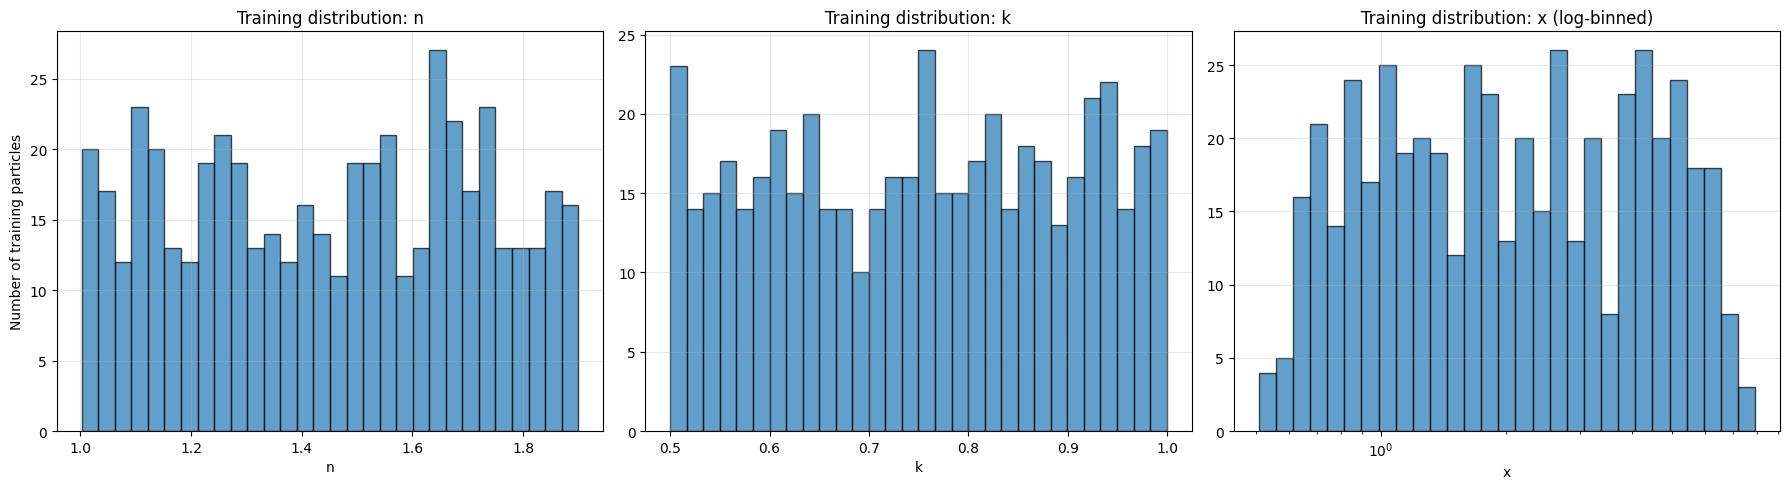

In [20]:
# Distribution of the TRAINING data (not the random test set) --
# checks whether x is actually under-sampled near x_max, which would
# explain rising error there without it being a fundamental model-capacity issue.

# `inputs` is the array returned by generate_dataset() -- shape (N_PARTICLES * N_ANGLES, 4),
# columns are [n, k, x, theta]. x is the SAME value repeated across all 181 angle-rows
# for a given particle, so pull one row per particle (every 181st row) rather than
# all of them, or particles with more angles wouldn't skew the count -- though here
# every particle has exactly 181 rows regardless, so it's really just "one sample per particle".

particle_n = inputs[::N_ANGLES, 0]
particle_k = inputs[::N_ANGLES, 1]
particle_x = inputs[::N_ANGLES, 2]

print(f"{len(particle_x)} particles in training set")
print(f"x range actually sampled: {particle_x.min():.3f} to {particle_x.max():.3f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(particle_n, bins=30, edgecolor='black', alpha=0.7)
axes[0].set_xlabel("n")
axes[0].set_ylabel("Number of training particles")
axes[0].set_title("Training distribution: n")
axes[0].grid(True, alpha=0.3)

axes[1].hist(particle_k, bins=30, edgecolor='black', alpha=0.7)
axes[1].set_xlabel("k")
axes[1].set_title("Training distribution: k")
axes[1].grid(True, alpha=0.3)

# log-spaced bins for x, since x itself is generated via a ratio of two
# log-uniform variables (diameter/wavelength) -- a linear-bin histogram
# would visually exaggerate the low-x pileup and hide structure at high-x
x_bins = np.logspace(np.log10(particle_x.min()), np.log10(particle_x.max()), 30)
axes[2].hist(particle_x, bins=x_bins, edgecolor='black', alpha=0.7)
axes[2].set_xscale('log')
axes[2].set_xlabel("x")
axes[2].set_title("Training distribution: x (log-binned)")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'm=1.5, Sphere Diameter = $\\lambda$/3')

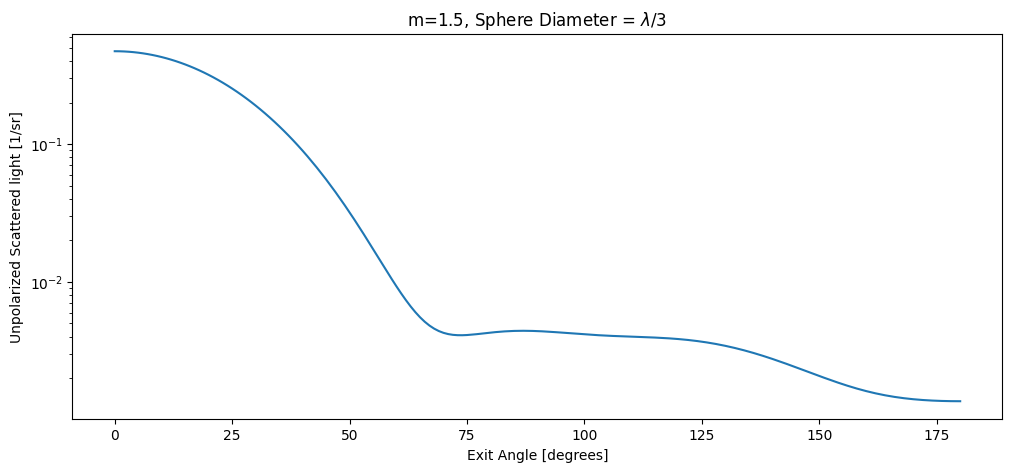

In [36]:
import miepython as mie

m = 1.5 - 0.5j          # refractive index, n=1.5, k=0.01
x = 3.0                  # size parameter
theta = np.linspace(0, 180, 181)   # degrees, 0 = forward, 180 = backward
mu = np.cos(np.radians(theta))     # just cos(theta), same info, different variable

scat = mie.i_unpolarized(m, x, mu)    # scattering intensity at each theta

fig, ax = plt.subplots(1, 1, figsize=(12, 5))
plt.plot(theta, scat)
plt.yscale('log')
plt.xlabel("Exit Angle [degrees]")
plt.ylabel("Unpolarized Scattered light [1/sr]")
plt.title(r"m=1.5, Sphere Diameter = $\lambda$/3")